# LangGraph

LangChain provides tools for building applications with language models. LangGraph is used to create stateful workflows made of nodes and edges.

### Main concepts

- **State**: Data shared between nodes.
- **Nodes**: Python functions that perform work.
- **Edges**: Connections between nodes.
- **Conditional edges**: Routing logic that selects the next node.
- **START**: Graph entry point.
- **END**: Graph exit point.

## Define Graph State

The state is passed between nodes. Nodes return a dictionary containing the values they want to update.

In [39]:
from dotenv import load_dotenv
from typing import TypedDict
load_dotenv()

class GraphState(TypedDict):
    message: str
    result: str

## Create Nodes

A node is a Python function that receives the current state and returns state updates.

In [40]:
def first_node(state: GraphState):
    return {
        "result": f"Processed: {state['message']}"
    }


def second_node(state: GraphState):
    return {
        "result": state["result"].upper()
    }

## Create a Basic Graph

The graph runs from `START` to `END` through the configured nodes.

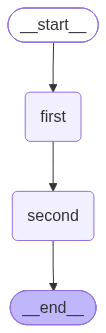

In [41]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(GraphState)

builder.add_node("first", first_node)
builder.add_node("second", second_node)

builder.add_edge(START, "first")
builder.add_edge("first", "second")
builder.add_edge("second", END)

graph = builder.compile()

graph_image = graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [42]:
result = graph.invoke({
    "message": "hello langgraph",
    "result": ""
})

print(result)

{'message': 'hello langgraph', 'result': 'PROCESSED: HELLO LANGGRAPH'}


## Edges

Edges define the execution order:

```python
builder.add_edge("source_node", "destination_node")
```

A graph can also have multiple branches. Independent branches may execute in parallel.

## Conditional Edges

Conditional edges choose the next node based on the current state.

In [43]:
from typing import Literal, TypedDict


class RouteState(TypedDict):
    input: str
    category: str
    response: str


def classify(state: RouteState):
    text = state["input"].lower()
    category = "billing" if "price" in text else "general"
    return {"category": category}


def billing_node(state: RouteState):
    return {"response": "This is a billing question."}


def general_node(state: RouteState):
    return {"response": "This is a general question."}


def route_question(state: RouteState) -> Literal["billing", "general"]:
    return state["category"]

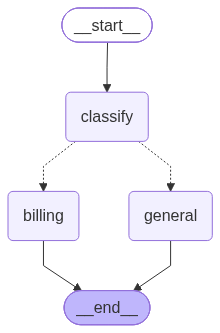

In [44]:
route_builder = StateGraph(RouteState)

route_builder.add_node("classify", classify)
route_builder.add_node("billing", billing_node)
route_builder.add_node("general", general_node)

route_builder.add_edge(START, "classify")

route_builder.add_conditional_edges(
    "classify",
    route_question,
    {
        "billing": "billing",
        "general": "general",
    }
)

route_builder.add_edge("billing", END)
route_builder.add_edge("general", END)

route_graph = route_builder.compile()

graph_image = route_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [45]:
route_graph.invoke({
    "input": "What is the price?",
    "category": "",
    "response": ""
})

{'input': 'What is the price?',
 'category': 'billing',
 'response': 'This is a billing question.'}

## Using a LangChain Model in a Node

A LangChain chat model can be called from inside a LangGraph node.

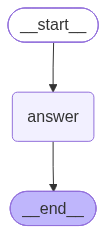

In [46]:
from langchain.chat_models import init_chat_model


model = init_chat_model(
    model="groq:openai/gpt-oss-20b"
)


class ChatState(TypedDict):
    question: str
    answer: str


def answer_question(state: ChatState):
    response = model.invoke(state["question"])
    return {"answer": response.content}


chat_builder = StateGraph(ChatState)
chat_builder.add_node("answer", answer_question)
chat_builder.add_edge(START, "answer")
chat_builder.add_edge("answer", END)

chat_graph = chat_builder.compile()
graph_image = chat_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [47]:
chat_graph.invoke({
    "question": "What is LangGraph?",
    "answer": ""
})

{'question': 'What is LangGraph?',
 'answer': '**LangGraph** is an open‑source framework for building, executing, and managing *graph‑based* language‑model workflows. It lets you turn a series of prompts, LLM calls, and auxiliary functions into a directed graph where nodes represent individual computation steps and edges encode the flow of data (the “state”) between them.\n\n---\n\n## Core Concepts\n\n| Concept | What it is | Why it matters |\n|---------|------------|----------------|\n| **Node** | A unit of work – e.g., a prompt to an LLM, a function call, a data‑retrieval step. | Encapsulates logic so you can reuse, test, and reason about each step in isolation. |\n| **Edge** | A directed connection that passes the *state* from one node to the next. | Controls the order of execution and allows for branching, loops, and parallelism. |\n| **State** | A dictionary (or custom object) that carries information (user input, LLM responses, metadata) through the graph. | Enables context‑aware

## Using Reducers

A reducer controls how updates to the same state field are combined.

Without a reducer, a later node update replaces the previous value. With a reducer, updates can be accumulated. Reducers are especially useful when multiple nodes run in parallel.

Common reducers include:

- `operator.add` for lists, strings, or numbers
- `add_messages` for LangChain message objects

### Reducer Syntax

```python
class State(TypedDict):
    items: Annotated[list[str], operator.add]
```

When a node returns:

```python
{"items": ["new item"]}
```

the reducer combines it with the existing value instead of replacing the value.

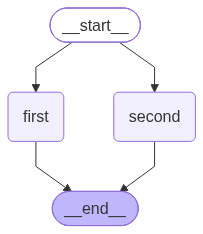

In [48]:
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END


class ReducerState(TypedDict):
    messages: Annotated[list[str], operator.add]


def first_message(state: ReducerState):
    return {"messages": ["Message from the first node"]}


def second_message(state: ReducerState):
    return {"messages": ["Message from the second node"]}


reducer_builder = StateGraph(ReducerState)

reducer_builder.add_node("first", first_message)
reducer_builder.add_node("second", second_message)

# Both nodes run from START and update the same field.
reducer_builder.add_edge(START, "first")
reducer_builder.add_edge(START, "second")

reducer_builder.add_edge("first", END)
reducer_builder.add_edge("second", END)

reducer_graph = reducer_builder.compile()
graph_image = reducer_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [49]:
reducer_result = reducer_graph.invoke({
    "messages": []
})

print(reducer_result["messages"])

['Message from the first node', 'Message from the second node']


### Message Reducer

For chat applications, use LangGraph's `add_messages` reducer. It appends new messages and handles message updates by message ID.

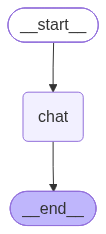

In [50]:
from typing import Annotated
from langchain_core.messages import AnyMessage, HumanMessage
from langgraph.graph import StateGraph, START, END, add_messages

class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

def add_user_message(state: MessageState):
    return {"messages":[HumanMessage("Hello langgraph!")]}

chat_builder = StateGraph(state_schema=MessageState)

chat_builder.add_node('chat', add_user_message)

chat_builder.add_edge(START, "chat")
chat_builder.add_edge("chat", END)

chat_graph = chat_builder.compile()

graph_image = chat_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [51]:
chat_graph.invoke({"messages":HumanMessage("Hi")})

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='139b0de8-adb2-4f52-b779-45072701c04d'),
  HumanMessage(content='Hello langgraph!', additional_kwargs={}, response_metadata={}, id='20a96d33-152a-4a61-b115-381ee773fe51')]}

# Tool Binding

In [52]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

# Define model
model = init_chat_model(
    "groq:openai/gpt-oss-20b",
    temperature=0
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b

@tool
def subtract(a: int, b: int) -> int:
    """Subtracts `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a - b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, subtract, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [53]:
# The graph’s state is used to store the messages and the number of LLM calls.
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

In [54]:
# The model node is used to call the LLM and decide whether to call a tool or not.
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

In [55]:
from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

In [56]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

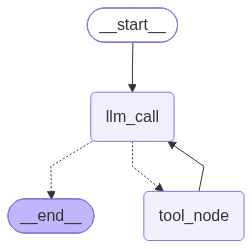

In [57]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [58]:
# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (fc_e9a29228-7fd6-4642-b705-58ea0777280d)
 Call ID: fc_e9a29228-7fd6-4642-b705-58ea0777280d
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.


## Common Graph Pattern

```text
START
  ↓
Input Processing
  ↓
Classify / Decide
  ↓
Conditional Route
  ├── Tool Node
  ├── Retrieval Node
  └── LLM Node
        ↓
      END
```

### Important methods

```python
builder.add_node("name", function)
builder.add_edge("source", "destination")
builder.add_conditional_edges("source", routing_function, path_map)
builder.compile()
graph.invoke(initial_state)
```

LangGraph is useful for workflows involving branching, tools, retrieval, retries, memory, human approval, and multiple agent steps.